In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# Parameters

alpha = 0.7

# Number of time bins
M = 100

# Equal prior probabilities
priors = np.ones(4) / 4

In [ ]:
# Four coherent-state amplitudes

state_amplitudes = np.array([alpha, 1j * alpha, -alpha, -1j * alpha])

state_labels = [r"$|\alpha\rangle$", r"$|i\alpha\rangle$", r"$|-\alpha\rangle$", r"$|-i\alpha\rangle$"]

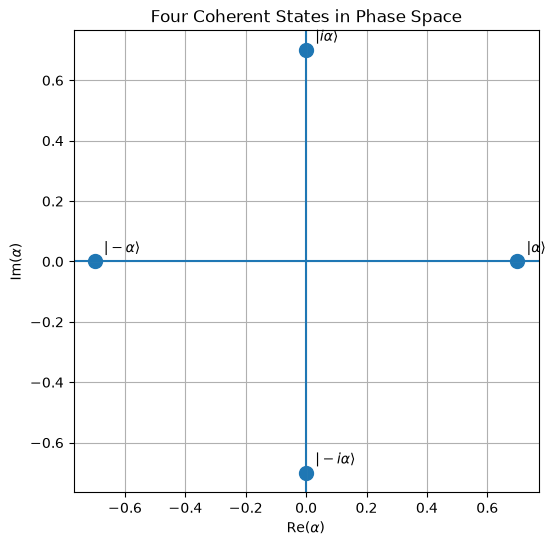

In [ ]:
plt.figure(figsize=(6, 6))

plt.scatter(np.real(state_amplitudes), np.imag(state_amplitudes), s=100)

for k, amplitude in enumerate(state_amplitudes):

    plt.text(np.real(amplitude) + 0.03, np.imag(amplitude) + 0.03, state_labels[k])

plt.axhline(0)
plt.axvline(0)

plt.xlabel(r"Re$(\alpha)$")
plt.ylabel(r"Im$(\alpha)$")
plt.title("Four Coherent States in Phase Space")

plt.grid()
plt.axis("equal")
plt.show()

In [ ]:
def click_probabilities(amplitude):

    mean_photons = np.abs(amplitude)**2

    P_no_click = np.exp(-mean_photons)
    
    P_click = 1 - P_no_click

    return P_no_click, P_click

In [ ]:
def choose_displacement(probabilities, state_amplitudes, dt):
    """
    Null the currently most likely hypothesis.
    """

    # Find the most likely hypothesis
    most_likely = np.argmax(probabilities)

    # Corresponding coherent amplitude
    gamma = state_amplitudes[most_likely]

    # Displacement that nulls this state
    beta = -gamma * np.sqrt(dt)

    return beta, most_likely

In [ ]:
def bayesian_update(probabilities, likelihoods):
    """
    Update the probabilities of all hypotheses
    using Bayes' rule.
    """

    updated_probabilities = (probabilities*likelihoods
)

    normalization = np.sum(updated_probabilities)

    # Avoid division by zero
    if normalization > 1e-15:

        updated_probabilities /= normalization

    return updated_probabilities

In [ ]:
def four_state_receiver(true_state, alpha, M, store_history=False):
    """
    Adaptive receiver for four coherent states.

    Parameters
    true_state : int
        Index of the true input state:
        0 -> |alpha>
        1 -> |i alpha>
        2 -> |-alpha>
        3 -> |-i alpha>

    alpha : float
        Coherent-state amplitude.

    M : int
        Number of time bins.
    """

    # Define the four possible states

    state_amplitudes = np.array([alpha, 1j * alpha, -alpha, -1j * alpha])

    # Initial probabilities

    probabilities = np.ones(4) / 4

    # Time step
    dt = 1 / M

    # Store history

    probability_history = []
    click_history = []
    displacement_history = []
    most_likely_history = []

    # Loop over time bins

    for step in range(M):

        # Choose adaptive displacement

        beta, most_likely = choose_displacement(probabilities, state_amplitudes, dt)

        # Calculate likelihoods for every hypothesis

        P_no_click = np.zeros(4)

        P_click = np.zeros(4)

        for k in range(4):

            # Signal amplitude in this time bin
            signal_bin = (state_amplitudes[k] * np.sqrt(dt))

            # Amplitude after displacement
            detector_amplitude = (signal_bin + beta)

            # Measurement probabilities
            P_no_click[k], P_click[k] = (click_probabilities( detector_amplitude))

        # Generate the actual detector result

        true_amplitude = (state_amplitudes[true_state]*np.sqrt(dt) + beta)

        _, P_click_actual = click_probabilities(true_amplitude)

        click = (np.random.random() < P_click_actual)

        # Bayesian update

        if click:
            likelihoods = P_click

        else:
            likelihoods = P_no_click

        probabilities = bayesian_update(probabilities, likelihoods)

        # Store results

        if store_history:

            probability_history.append(probabilities.copy())
            click_history.append(click)
            displacement_history.append(beta)
            most_likely_history.append(most_likely)

    # Final decision

    decision = np.argmax(probabilities)

    history = {"probabilities": np.array(probability_history), "clicks": np.array(click_history), "displacements": np.array(displacement_history), "most_likely": np.array(most_likely_history)}

    return decision, history

In [ ]:
true_state = 0

decision, history = four_state_receiver(true_state=true_state, alpha=alpha, M=M, store_history=True)

print("True state:", state_labels[true_state])

print("Final decision:", state_labels[decision])

True state: $|\alpha\rangle$
Final decision: $|\alpha\rangle$


In [ ]:
def calculate_four_state_error(alpha, M=100, n_trials=1000):
    errors = 0

    # Loop over all four possible input states
    for true_state in range(4):

        for _ in range(n_trials):

            decision, _ = four_state_receiver(true_state=true_state, alpha=alpha, M=M)

            # Incorrect decision
            if decision != true_state:
                errors += 1

    total_trials = 4 * n_trials

    return errors / total_trials

In [ ]:
P_error = calculate_four_state_error(alpha=0.7, M=100, n_trials=5000)

print("Four-state adaptive receiver error:", P_error)

Four-state adaptive receiver error: 0.4354


In [ ]:
alphas = np.linspace(0.1, 2.0, 20)

P_errors = []

for alpha_value in alphas:

    error = calculate_four_state_error(alpha=alpha_value, M=100, n_trials=2000)
    P_errors.append(error)

P_errors = np.array(P_errors)

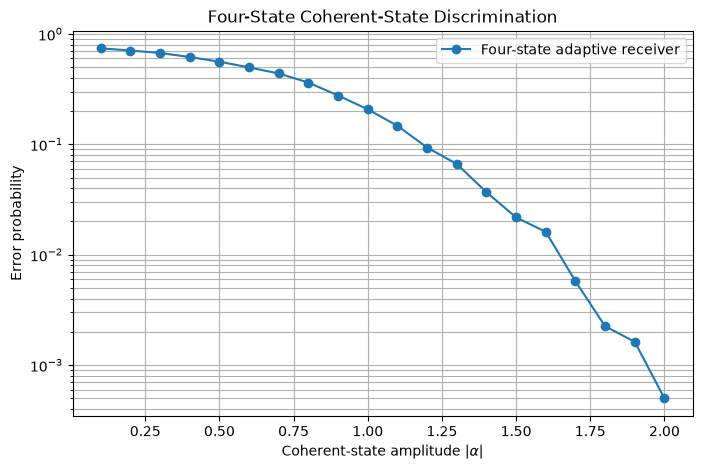

In [ ]:
plt.figure(figsize=(8, 5))
plt.semilogy(alphas, P_errors, "o-", label="Four-state adaptive receiver")

plt.xlabel(r"Coherent-state amplitude $|\alpha|$")
plt.ylabel(r"Error probability")
plt.title("Four-State Coherent-State Discrimination")

plt.grid(True, which="both")
plt.legend()
plt.show()

In [ ]:
def ideal_four_state_error(alpha):
    """
    Calculate the minimum possible error probability for four equally likely symmetric coherent states:
        |alpha>
        |i alpha>
        |-alpha>
        |-i alpha>
    """

    # Four coherent-state amplitudes
    state_amplitudes = np.array([alpha, 1j * alpha, -alpha, -1j * alpha])

    # Number of states
    K = len(state_amplitudes)

    # Construct the Gram matrix

    G = np.zeros((K, K), dtype=complex)

    for i in range(K):

        for j in range(K):

            gamma_i = state_amplitudes[i]
            gamma_j = state_amplitudes[j]

            # <gamma_i | gamma_j>
            G[i, j] = np.exp(-0.5 * np.abs(gamma_i)**2 - 0.5 * np.abs(gamma_j)**2 + np.conj(gamma_i) * gamma_j)

    # Eigenvalues of Gram matrix

    eigenvalues = np.linalg.eigvalsh(G)

    # Numerical safeguard
    eigenvalues = np.clip(eigenvalues, 0, None)

    # Ideal success probability

    P_success = (np.sum(np.sqrt(eigenvalues))**2/K**2)

    # Ideal error probability
    P_error = 1 - P_success

    return P_error

In [ ]:
alphas = np.linspace(0.1, 2.0, 20)

P_adaptive = []
P_ideal = []

In [ ]:
for alpha_value in alphas:

    # Adaptive nulling receiver
    adaptive_error = calculate_four_state_error(alpha=alpha_value, M=100, n_trials=2000)

    P_adaptive.append(adaptive_error)

    # Ideal quantum measurement
    ideal_error = ideal_four_state_error(alpha_value)

    P_ideal.append(ideal_error)


P_adaptive = np.array(P_adaptive)
P_ideal = np.array(P_ideal)

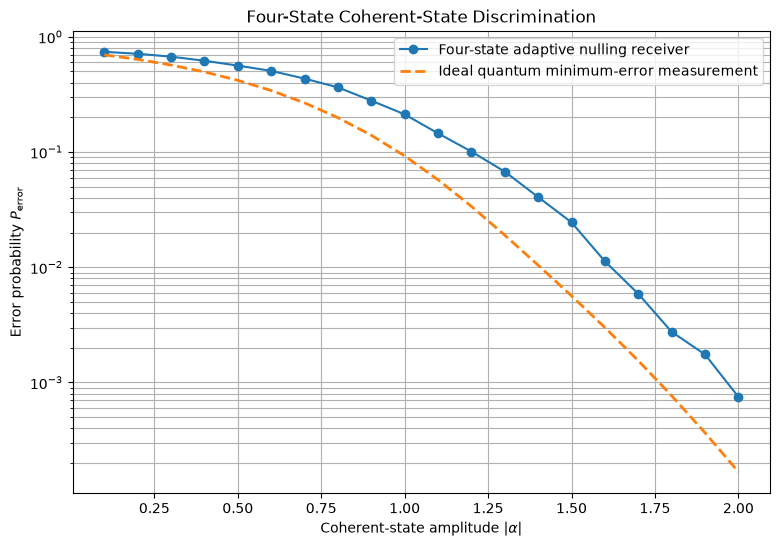

In [ ]:
plt.figure(figsize=(9, 6))
plt.semilogy(alphas, P_adaptive, "o-", label="Four-state adaptive nulling receiver")
plt.semilogy(alphas, P_ideal, "--", linewidth=2, label="Ideal quantum minimum-error measurement")

plt.xlabel(r"Coherent-state amplitude $|\alpha|$")
plt.ylabel( r"Error probability $P_{\mathrm{error}}$")
plt.title( "Four-State Coherent-State Discrimination")

plt.grid(True, which="both")
plt.legend()
plt.show()